Case Classificando bebidas
Será que é possível classificarmos o tipo de bebida dado alguns atributos como volume, quantidade de calorias e quantidade de cafeína? -- subindo

Na aula de hoje vamos explorar o dataset caffeine para construirmos um classificador com base em modelos de árvores.

Atributos
bebida: nome da bebida.

Volume (ml): Quantidade em volume.

Calorias: Quantidade de calorias.

Cafeína(mg): Quantidade de cafeína.

tipo: tipo de bebida. (Café, Bebidas Energéticas, Shots Energéticos, Refrigerantes, Chá, Água)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn import tree

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import export_graphviz


In [2]:
dados = pd.read_csv("caffeine.csv", sep =",")

In [3]:
dados.shape

(610, 5)

In [4]:
dados.head()

,drink,Volume (ml),Calories,Caffeine (mg),type
0,Costa Coffee,256.993715,0,277,Coffee
1,Coffee Friend Brewed Coffee,250.191810,0,145,Coffee
2,Hell Energy Coffee,250.191810,150,100,Coffee
3,Killer Coffee (AU),250.191810,0,430,Coffee
4,Nescafe Gold,250.191810,0,66,Coffee


In [5]:
dados['type'].value_counts()

type
Energy Drinks    219
Coffee           173
Soft Drinks       90
Tea               66
Energy Shots      36
Water             26
Name: count, dtype: int64

In [6]:
set(dados['type'])

{'Coffee', 'Energy Drinks', 'Energy Shots', 'Soft Drinks', 'Tea', 'Water'}

In [7]:
dados.isnull().sum()

drink            0
Volume (ml)      0
Calories         0
Caffeine (mg)    0
type             0
dtype: int64

<Axes: xlabel='Volume (ml)'>

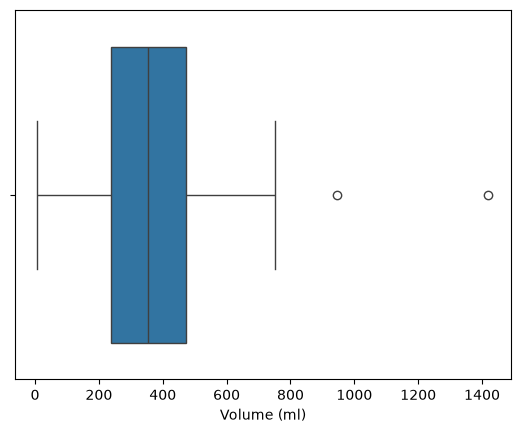

In [8]:
sb.boxplot(data = dados, x = 'Volume (ml)')

<Axes: xlabel='Calories', ylabel='Count'>

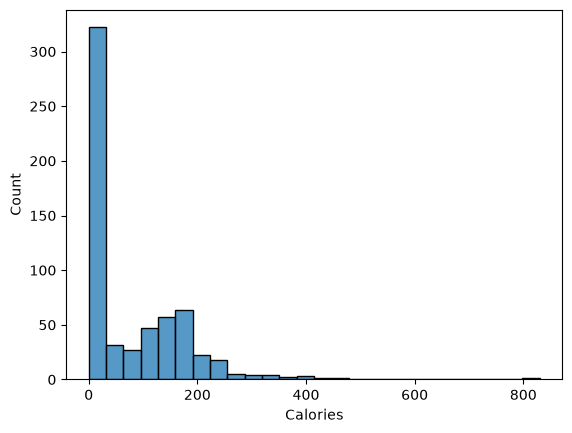

In [9]:
sb.histplot(data =dados, x = "Calories")

<Axes: xlabel='Caffeine (mg)', ylabel='Count'>

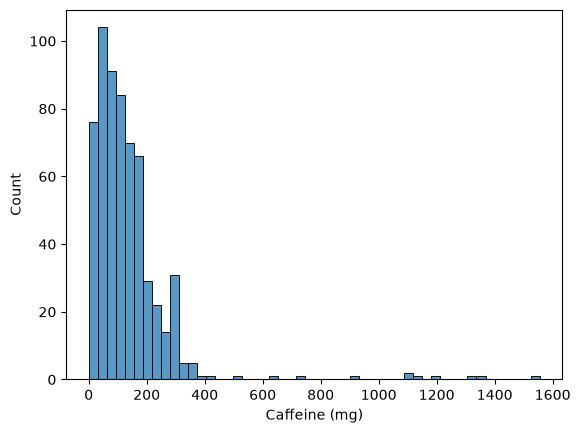

In [10]:
sb.histplot(data = dados, x ="Caffeine (mg)")

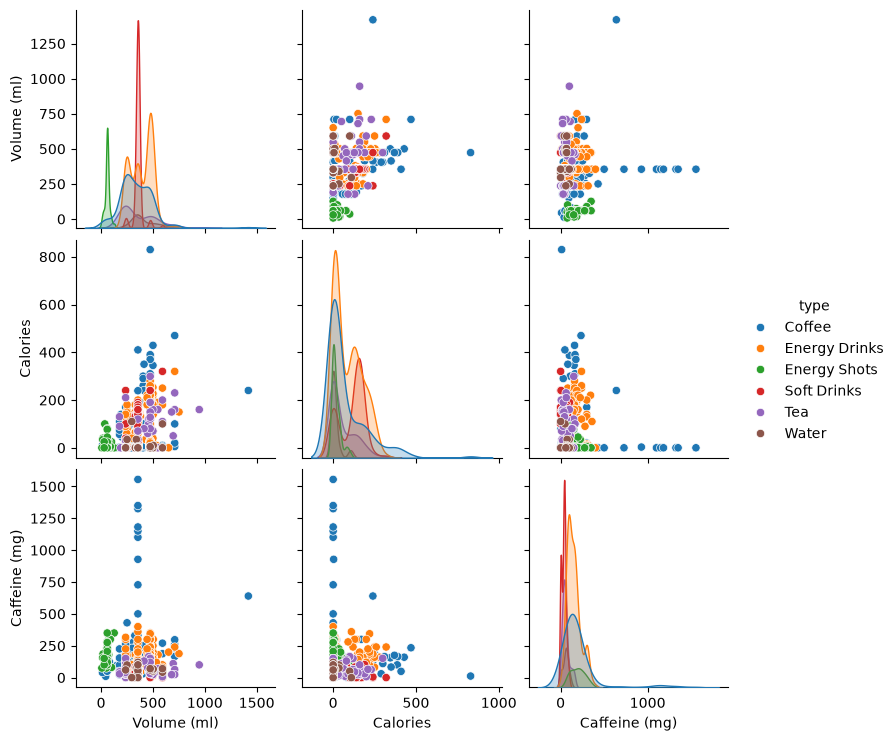

In [11]:
sb.pairplot(dados, vars = ['Volume (ml)', 'Calories', 'Caffeine (mg)'], hue = 'type')

In [12]:
#Separando os dados
x = dados.drop(columns = ['type', 'drink'])
y = dados['type']

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=7)

In [14]:
dt = DecisionTreeClassifier(random_state=7, criterion='gini', max_depth = 3)

In [15]:
dt.fit(x_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",7
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at t

In [16]:
DecisionTreeClassifier(max_depth=3, random_state=7)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",7
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at t

In [17]:
y_predito = dt.predict(x_test)

[Text(0.5, 0.875, 'x[2] <= 76.5\ngini = 0.752\nsamples = 488\nvalue = [138, 175, 29, 72, 53, 21]'),
 Text(0.25, 0.625, 'x[0] <= 312.888\ngini = 0.741\nsamples = 171\nvalue = [28, 16, 1, 67, 42, 17]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[0] <= 118.708\ngini = 0.653\nsamples = 60\nvalue = [24, 6, 1, 3, 25, 1]'),
 Text(0.0625, 0.125, 'gini = 0.219\nsamples = 8\nvalue = [7, 0, 1, 0, 0, 0]'),
 Text(0.1875, 0.125, 'gini = 0.645\nsamples = 52\nvalue = [17, 6, 0, 3, 25, 1]'),
 Text(0.375, 0.375, 'x[0] <= 367.451\ngini = 0.614\nsamples = 111\nvalue = [4, 10, 0, 64, 17, 16]'),
 Text(0.3125, 0.125, 'gini = 0.367\nsamples = 79\nvalue = [1, 4, 0, 62, 3, 9]'),
 Text(0.4375, 0.125, 'gini = 0.713\nsamples = 32\nvalue = [3, 6, 0, 2, 14, 7]'),
 Text(0.75, 0.625, 'x[0] <= 138.404\ngini = 0.619\nsamples = 317\nvalue = [110.0, 159.0, 28.0, 5.0, 11.0, 4.0]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[2] <= 131.5\ngini = 0.124\nsamples = 30\nvalue = [2, 0, 28, 0, 0, 0]'),
 Text(0

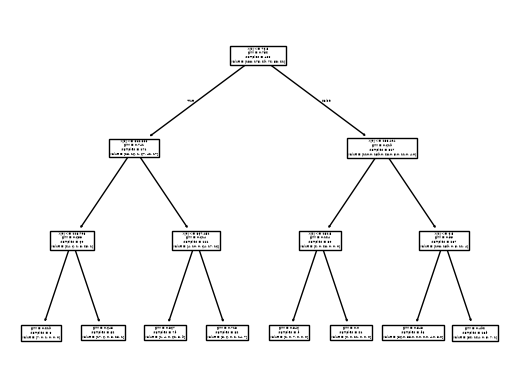

In [18]:
tree.plot_tree(dt)

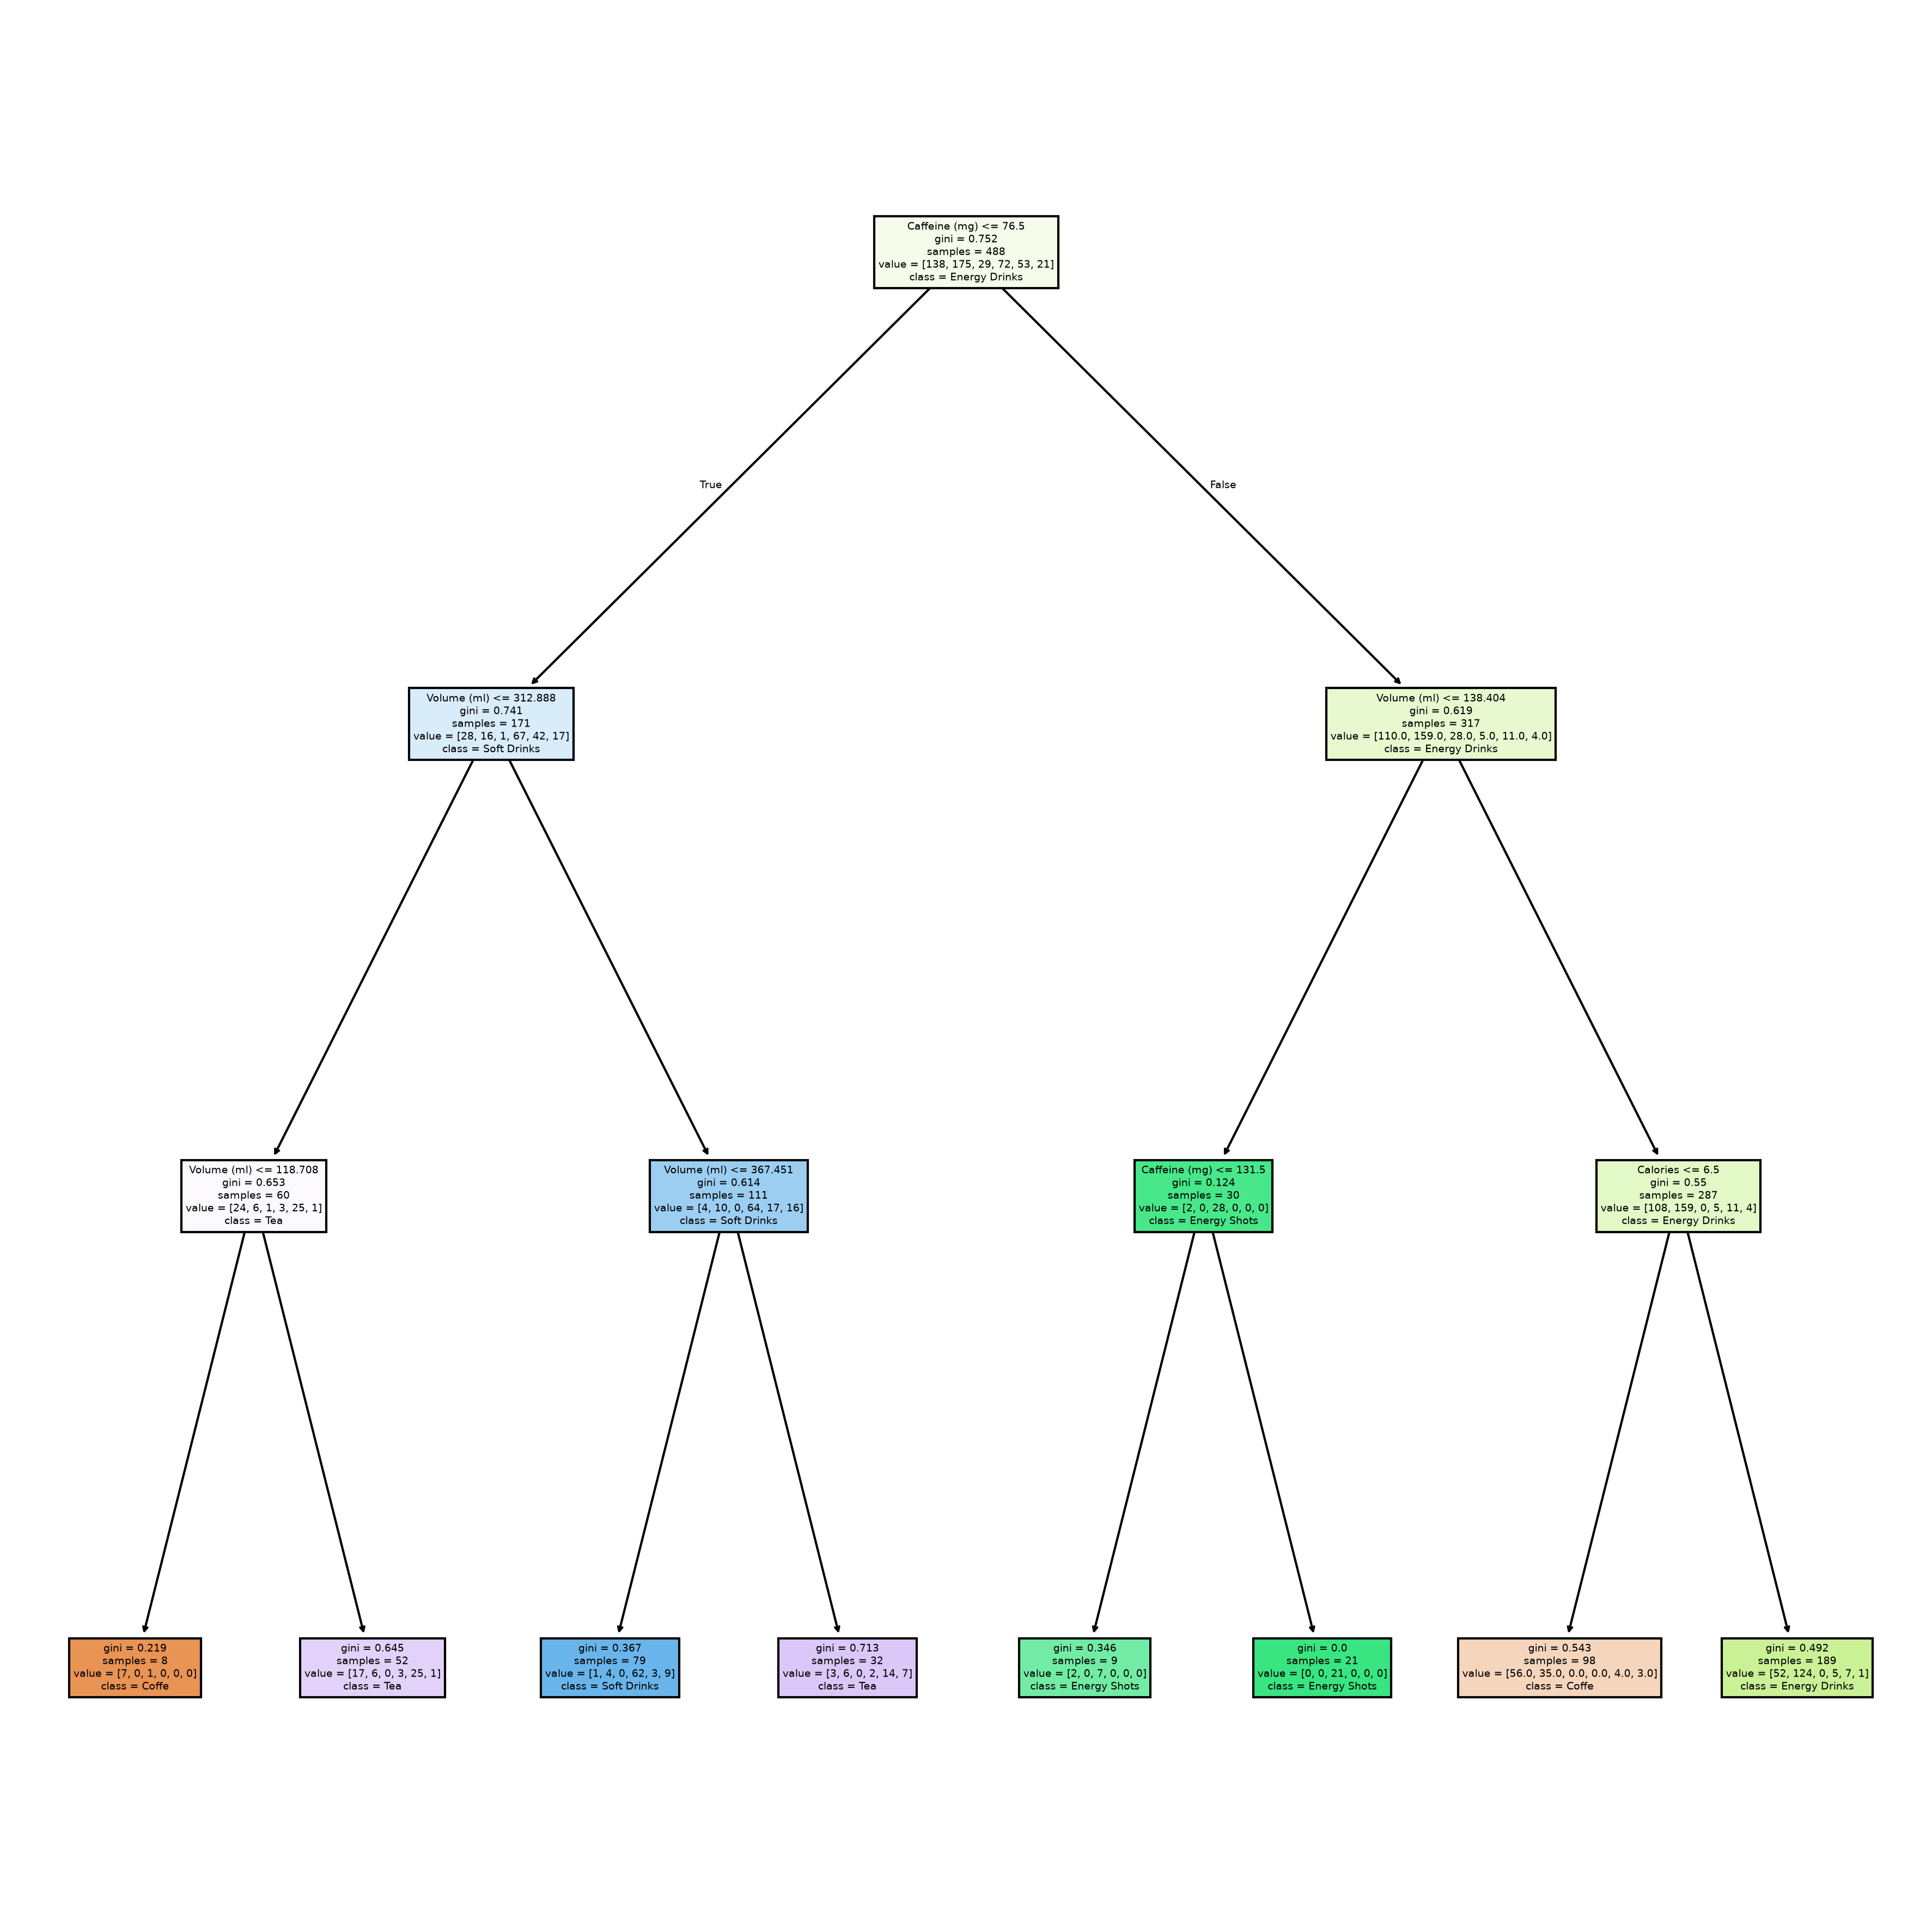

In [19]:
class_names = ['Coffe', 'Energy Drinks', 'Energy Shots', 'Soft Drinks', 'Tea', 'Water']
label_names = ['Volume (ml)', 'Calories', 'Caffeine (mg)']
fig, axes = plt.subplots(nrows = 1, ncols =1, figsize =(15,15), dpi = 300)
tree.plot_tree(dt,
               feature_names = label_names,
               class_names = class_names,
               filled = True)
fig.savefig('imagename.png')

In [20]:

print(accuracy_score(y_test, y_predito)) #relatório de validação das métrica de desempenho.

0.6557377049180327


In [21]:

dados['type'].value_counts()

type
Energy Drinks    219
Coffee           173
Soft Drinks       90
Tea               66
Energy Shots      36
Water             26
Name: count, dtype: int64

Se as variáveis target do seu modelo de decision tree não estão equilibradas, isso pode afetar a precisão e a acurácia do seu modelo, especialmente se a classe minoritária é importante para o seu problema.

Utilize algoritmos que são robustos a desequilíbrios de classe: Alguns algoritmos de machine learning são projetados para serem robustos a desequilíbrios de classe. Alguns exemplos incluem o Random Forests.

--Duas abordagens comuns são o ajuste do parâmetro class_weight e a aplicação de técnicas de reamostragem.
--Técnicas de reamostragem: Outra abordagem comum é usar técnicas de reamostragem, como oversampling e undersampling, para equilibrar as classes. Oversampling envolve a duplicação ou triplicação de observações da classe minoritária, enquanto undersampling envolve a redução do número de observações da classe majoritária. Isso ajuda a garantir que o modelo seja treinado com um número igual de observações para cada classe

In [22]:


from imblearn.over_sampling import SMOTE

In [ ]:
# Aplicar SMOTE para oversampling da classe minoritária
oversample = SMOTE()
x_train_os, y_train_os = oversample.fit_resample(x_train, y_train)

Nesse exemplo, SMOTE é utilizado para gerar dados sintéticos e equilibrar as classes antes de ajustar o modelo de Random Forest. Note que o método fit_resample é utilizado para aplicar o oversampling na classe minoritária. Por fim, o modelo é avaliado com a métrica de acurácia no conjunto de teste.

Oversampling envolve a criação de mais exemplos para a classe minoritária, aumentando sua representação no conjunto de dados. As técnicas comuns de oversampling incluem a replicação de exemplos existentes (cópia de exemplos da classe minoritária), a geração sintética de novos exemplos com base em exemplos existentes, como a técnica SMOTE (Synthetic Minority Over-sampling Technique), ou a combinação de ambas as abordagens.

In [24]:

x_train.shape

(488, 3)

In [25]:
x_train_os.shape

(1050, 3)

In [26]:

rf = RandomForestClassifier(criterion= 'entropy', n_estimators=80, max_depth = 7, class_weight = 'balanced', random_state=7) 

rf.fit(x_train_os, y_train_os) 


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",80
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",7
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

In [27]:


estimator_rf = rf.estimators_

In [28]:


y_predito_random_forest = rf.predict(x_test) 

In [29]:

print(accuracy_score(y_test, y_predito_random_forest)) #relatório de validação das métrica de desempenho.

0.7213114754098361


In [30]:

print (rf.score(x_train, y_train)) 
print(rf.score(x_test, y_test))

0.8524590163934426
0.7213114754098361
